### Importing Libraries

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

### Phase 1

### Load Dataset

In [10]:
data=pd.read_csv("movie_dataset_with_missing.csv")
df=pd.DataFrame(data)

### Observation:

- data has been loaded succesfully using pd.read_csv

### Preview Of The Dataset

In [11]:
df

,ShowID,Title,Year,Genre,Rating,Votes,Revenue,Budget,Country,Success/Failure,Director,StreamingPlatform
0,SHOW00001,Cross-platform empowering Local Area Network,2007.0,Drama,6.1,410108.0,88588701.0,19707121.0,Uzbekistan,Failure,Miranda Willis,Netflix
1,SHOW00002,Up-sized bottom-line artificial intelligence,1986.0,Horror,3.4,718965.0,615115333.0,37829747.0,New Zealand,Success,Joseph Glenn,Amazon Prime
2,SHOW00003,Progressive asynchronous flexibility,2017.0,Sci-Fi,3.3,293522.0,517193544.0,31972598.0,Saint Lucia,Success,Lisa Moore,Hulu
3,SHOW00004,Open-architected web-enabled encryption,2010.0,Adventure,4.1,361339.0,304402740.0,3107804.0,Slovakia (Slovak Republic),Failure,Jonathan Cantu,Amazon Prime
4,SHOW00005,Configurable systemic system engine,2014.0,Adventure,6.2,699047.0,517075712.0,48548229.0,El Salvador,Success,Alexis Cruz,Hulu
...,...,...,...,...,...,...,...,...,...,...,...,...
2195,SHOW02196,Mandatory motivating standardization,2003.0,Sci-Fi,7.1,861335.0,336887087.0,9894953.0,Australia,Failure,Daniel Barnett,Disney+
2196,SHOW02197,Open-architected leadingedge superstructure,2004.0,Action,6.8,306447.0,569669549.0,5030927.0,British Indian Ocean Territory (Chagos Archipe...,Success,Christian Delacruz,Hulu
2197,SHOW02198,Multi-tiered human-resource matrices,2002.0,Adventure,5.5,298952.0,54543100.0,11644634.0,Iceland,Failure,Scott Douglas,Disney+
2198,SHOW02199,Cross-platform zero-defect project,1986.0,Romance,3.1,708323.0,664167128.0,1562737.0,Serbia,Success,Valerie Gonzales,Disney+


### Understanding The Structure Of The Dataset

In [5]:
df.shape

(2200, 12)

### Observation:
 - The dataset contains 2200 rows and 12 columns representing various movies related information.

### Preview Of The First Few Rows

In [6]:
df.head()

,ShowID,Title,Year,Genre,Rating,Votes,Revenue,Budget,Country,Success/Failure,Director,StreamingPlatform
0,SHOW00001,Configurable context-sensitive support,2017.0,Comedy,6.6,663074.0,940909137.0,24285736.0,Turks and Caicos Islands,Success,Timothy Evans,Netflix
1,SHOW00002,Sharable exuding process improvement,2016.0,Sci-Fi,7.1,107103.0,26485416.0,6587001.0,India,Failure,Lisa Cummings,Disney+
2,SHOW00003,Compatible content-based orchestration,1990.0,Action,8.3,894742.0,515824941.0,26909964.0,French Southern Territories,Success,Raymond Becker MD,Amazon Prime
3,SHOW00004,Intuitive leadingedge knowledgebase,2017.0,Comedy,8.3,511769.0,995124225.0,20117617.0,North Macedonia,Success,Kylie Mason,Disney+
4,SHOW00005,Phased solution-oriented attitude,1993.0,Horror,6.0,273337.0,496576264.0,11337946.0,Switzerland,Failure,Vincent Haney,Hulu


### Observation:
 - The preview shows the first few rows of the data and helps us check if the file loaded correctly.

### Dataset Structure and its DataTypes

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ShowID             2200 non-null   object 
 1   Title              2200 non-null   object 
 2   Year               2186 non-null   float64
 3   Genre              2197 non-null   object 
 4   Rating             2191 non-null   float64
 5   Votes              2193 non-null   float64
 6   Revenue            2187 non-null   float64
 7   Budget             2194 non-null   float64
 8   Country            2189 non-null   object 
 9   Success/Failure    2200 non-null   object 
 10  Director           2200 non-null   object 
 11  StreamingPlatform  2200 non-null   object 
dtypes: float64(5), object(7)
memory usage: 206.4+ KB


### Observation:

 -The dataset contains 2,200 movie records with 12 columns. 
 
- Out of these:
- 7 are categorical (ShowID, Title, Genre, Country, Success/Failure, Director, StreamingPlatform).

 - 5 are numerical (Year, Rating, Votes, Revenue, Budget).

- Several columns have missing values, especially in Year, Genre, Rating, Votes, Revenue, Budget, and Country. The other fields are complete.

- The dataset captures key aspects of movies, such as their production (Budget, Director), performance (Revenue, Success/Failure, Votes, Rating), and distribution (StreamingPlatform, Country).

- The file is lightweight (~206 KB), making it efficient to process and analyze.

### Statistical Overview of Numerical Data

In [8]:
df.describe()

,Year,Rating,Votes,Revenue,Budget
count,2186.000000,2191.000000,2193.000000,2.187000e+03,2.194000e+03
mean,2000.931382,5.962392,485056.334701,5.054515e+08,2.546189e+07
std,12.534286,1.701375,283810.590747,2.887554e+08,1.425104e+07
min,1980.000000,3.000000,1047.000000,1.178148e+06,5.232090e+05
25%,1990.000000,4.500000,238973.000000,2.608307e+08,1.288529e+07
50%,2001.000000,5.900000,476640.000000,5.072923e+08,2.551984e+07
75%,2011.000000,7.400000,728562.000000,7.535106e+08,3.774255e+07
max,2022.000000,9.000000,999572.000000,9.973915e+08,4.998242e+07


### Observation:

 - The average movie costs around 25 million dollars to produce and earns approximately 500 million dollars, indicating about a 20× return on investment.

 - Ratings are moderately distributed — most movies fall in the 5–7 range.

 - Vote count variation suggests a mix of indie and blockbuster films.

 - The years span 1980–2022, covering over 4 decades of movie data.

### Null Value Count Across All Columns

In [9]:
df.isnull().sum()

ShowID                0
Title                 0
Year                 14
Genre                 3
Rating                9
Votes                 7
Revenue              13
Budget                6
Country              11
Success/Failure       0
Director              0
StreamingPlatform     0
dtype: int64

### Percentage Of Missing Values


In [10]:
round(df.isnull().sum()/len(df)*100)/2

ShowID               0.0
Title                0.0
Year                 0.5
Genre                0.0
Rating               0.0
Votes                0.0
Revenue              0.5
Budget               0.0
Country              0.0
Success/Failure      0.0
Director             0.0
StreamingPlatform    0.0
dtype: float64

### Observation:

 - The dataset is almost complete — only Year and Revenue columns have 0.5% missing values, which is very minimal and won’t significantly affect analysis.


 - All other columns such as Title, Genre, Rating, Votes, Budget, and Director have no missing values, ensuring strong data consistency.


 - Overall, the dataset is clean, reliable, and analysis-ready, requiring only minor handling for the small percentage of missing data.



### Filling The Null Values Using Mode Function

In [11]:
df["Year"].mode()

0    2000.0
Name: Year, dtype: float64

In [12]:
df["Year"].fillna(df["Year"].mode()[0],inplace=True)

In [13]:
df["Genre"].mode()

0    Romance
Name: Genre, dtype: object

In [14]:
df["Genre"].fillna(df["Genre"].mode()[0],inplace=True)

In [15]:
df["Rating"].mode()

0    7.1
Name: Rating, dtype: float64

In [16]:
df["Rating"].fillna(df["Rating"].mode()[0],inplace=True)

In [17]:
df["Votes"].mode()

0    604690.0
1    777107.0
Name: Votes, dtype: float64

In [18]:
df["Votes"].fillna(df["Votes"].mode()[0],inplace=True)

In [19]:
df["Revenue"].mode()

0         1178148.0
1         1900419.0
2         2153326.0
3         2453213.0
4         2757569.0
           ...     
2182    996873282.0
2183    997111160.0
2184    997340202.0
2185    997386777.0
2186    997391539.0
Name: Revenue, Length: 2187, dtype: float64

In [20]:
df["Revenue"].fillna(df["Revenue"].mode()[0],inplace=True)

In [21]:
df["Budget"].mode()

0         523209.0
1         559036.0
2         578170.0
3         619503.0
4         650485.0
           ...    
2189    49899919.0
2190    49925698.0
2191    49929680.0
2192    49955246.0
2193    49982419.0
Name: Budget, Length: 2194, dtype: float64

In [22]:
df["Budget"].fillna(df["Budget"].mode()[0],inplace=True)

In [23]:
df["Country"].mode()

0                         Egypt
1                        France
2    Slovakia (Slovak Republic)
Name: Country, dtype: object

In [24]:
df["Country"].fillna(df["Country"].mode()[0],inplace=True)

In [25]:
df.isnull().sum()

ShowID               0
Title                0
Year                 0
Genre                0
Rating               0
Votes                0
Revenue              0
Budget               0
Country              0
Success/Failure      0
Director             0
StreamingPlatform    0
dtype: int64

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ShowID             2200 non-null   object 
 1   Title              2200 non-null   object 
 2   Year               2200 non-null   float64
 3   Genre              2200 non-null   object 
 4   Rating             2200 non-null   float64
 5   Votes              2200 non-null   float64
 6   Revenue            2200 non-null   float64
 7   Budget             2200 non-null   float64
 8   Country            2200 non-null   object 
 9   Success/Failure    2200 non-null   object 
 10  Director           2200 non-null   object 
 11  StreamingPlatform  2200 non-null   object 
dtypes: float64(5), object(7)
memory usage: 206.4+ KB


### Value Count Summary — Movies Dataset

### 1.ShowID

- Unique identifier for each movie/show.

- Complete, no missing values.

### 2.Title

- Name of the movie/show.

- Complete, no missing values.

### 3.Year

- Release year of the movie (currently stored as float, should ideally be integer).

- Complete, no missing values.

### 4.Genre

- Category/type of the movie (Action, Drama, Comedy, Thriller, etc.).

- Complete, no missing values.

### 5.Rating

- Average audience/critic rating (e.g., IMDb-style).

- Numeric values (float).

- Complete, no missing values.

### 6.Votes

- Number of votes submitted by viewers.

- Helps measure popularity.

- Complete, no missing values.

### 7.Revenue

- Box office earnings (likely in millions USD).

- Useful for profitability analysis.

- Complete, no missing values.

### 8.Budget

- Estimated production cost (in millions USD).

- Can be compared with revenue for ROI.

- Complete, no missing values.

### 9.Country

- Country where the movie was produced/released.

- Complete, no missing values.

### 10.Success/Failure

- Indicates if the movie was a success (profitable) or failure (loss).

- Complete, no missing values.

### 11.Director

- Name of the director.

- Can be analyzed for director-specific success rates.

- Complete, no missing values.

### 12.StreamingPlatform

- Online platform where the movie is available (Netflix, Prime, Hulu, etc.).

- Complete, no missing values.

In [27]:
df["Title"].value_counts()

Title
Balanced neutral extranet                 1
Configurable context-sensitive support    1
Sharable exuding process improvement      1
Compatible content-based orchestration    1
Intuitive leadingedge knowledgebase       1
                                         ..
Exclusive multimedia complexity           1
Realigned zero tolerance adapter          1
Face-to-face scalable standardization     1
User-centric multi-tasking synergy        1
Advanced heuristic migration              1
Name: count, Length: 2200, dtype: int64

### Observation:

 - Each movie title appears exactly once, confirming that there are no duplicate entries in the dataset.
 - The total of 2,200 unique titles matches the dataset size, ensuring data uniqueness.
 - Overall, the Title column is clean and reliable for identification or indexing purposes.


In [28]:
df["Genre"].value_counts()

Genre
Romance      302
Action       289
Horror       286
Drama        284
Comedy       283
Sci-Fi       262
Adventure    261
Thriller     233
Name: count, dtype: int64

### Observation:

 - The dataset includes eight movie genres, with Romance (302) being the most common and Thriller (233) the least.
 - This shows a balanced distribution across genres, with a slight dominance of Romance and Action films.
  

In [29]:
df["Country"].value_counts()

Country
Egypt                         28
France                        17
Slovakia (Slovak Republic)    17
Niue                          16
Germany                       16
                              ..
Israel                         3
Colombia                       3
Belize                         3
Singapore                      3
Solomon Islands                3
Name: count, Length: 242, dtype: int64

### Observation:

 - The dataset contains movies from 242 countries, showing high geographical diversity.
 - Egypt (28) has the highest representation, while several countries like Singapore and Israel have only a few entries.

In [30]:
df["Director"].value_counts()

Director
Anthony Smith                3
Heather Smith                3
Michelle Smith               3
Daniel Smith                 3
Michael Thomas               2
                            ..
Sheila Barber                1
Kevin Gomez                  1
Mr. Christopher Fowler MD    1
Daniel Colon                 1
Mitchell Merritt             1
Name: count, Length: 2156, dtype: int64

### Observation:

 - The dataset includes 2,156 unique directors, indicating strong diversity in creators.
 - A few directors like Anthony Smith and Heather Smith have directed multiple films (up to 3), while most directed only one.

In [31]:
df["StreamingPlatform"].value_counts

<bound method IndexOpsMixin.value_counts of 0            Netflix
1            Disney+
2       Amazon Prime
3            Disney+
4               Hulu
            ...     
2195            Hulu
2196         Disney+
2197         Disney+
2198         Netflix
2199    Amazon Prime
Name: StreamingPlatform, Length: 2200, dtype: object>

### Observation:

 - The dataset features movies from multiple streaming platforms such as Netflix, Disney+, Amazon Prime, and Hulu.
 - This indicates a diverse distribution across major OTT platforms, useful for platform-based performance analysis.

In [32]:
df.duplicated().value_counts()

False    2200
Name: count, dtype: int64

### Observation:

 - The dataset has no duplicate values, confirming data uniqueness and integrity.
 - It is clean and reliable for further analysis or modeling.

### Non-Visual Bivariate Analysis:

- Understand relationships between key variables without using graphs.

### Detecting Outliers

 - The IQR (Interquartile Range) method was used to detect outliers in all numerical columns as part of the non-visual analysis.

### Steps:
 - Calculate Q1 (25th percentile) and Q3 (75th percentile)
 - Compute IQR = Q3 - Q1
 - Define lower and upper bounds:
 - Lower bound = Q1 − 1.5 × IQR
 -  Upper bound = Q3 + 1.5 × IQR
 -  Any value outside this range is considered an outlier

In [27]:
import numpy as np

# Step 1: Get numeric columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Step 2: Detect and handle outliers
outliers = {}

for col in numerical_cols:
    if df[col].isnull().all():
        continue
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Detect outliers
    outlier_values = df[(df[col] < lower) | (df[col] > upper)][col]
    if not outlier_values.empty:
        outliers[col] = outlier_values.tolist()
    
    # Cap outliers
    df[col] = np.where(df[col] < lower, lower,
              np.where(df[col] > upper, upper, df[col]))

# Step 3: Print detected outliers
if outliers:
    for col, vals in outliers.items():
        print(f"\nOutliers in column '{col}':\n{vals}")
else:
    print("No outliers found in the numerical columns.")


No outliers found in the numerical columns.


### Phase 2

### Data Visualization

### Univariate Analysis

### 1 Count of Shows per Streaming Platform

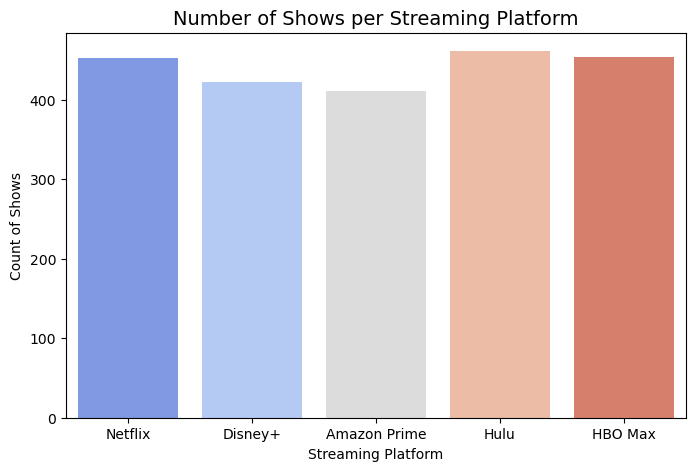

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(x='StreamingPlatform', data=df, palette='coolwarm')
plt.title('Number of Shows per Streaming Platform', fontsize=14)
plt.xlabel('Streaming Platform')
plt.ylabel('Count of Shows')
plt.show()


### Observation:

 - Netflix and Disney+ have the highest number of shows, indicating stronger content libraries.
 - Hulu and Amazon Prime have fewer titles comparatively.

### 2.Distribution of Movie Ratings

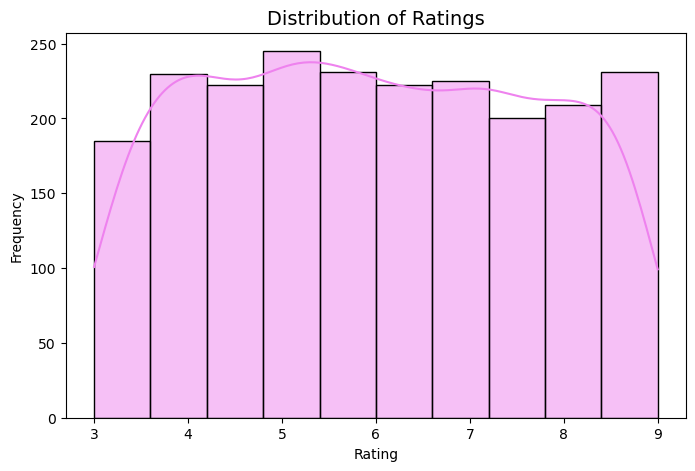

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(df['Rating'], bins=10, kde=True, color = "violet")
plt.title('Distribution of Ratings', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()


### Observation:

 - Ratings are mostly between 6–8, showing that most shows receive average to above-average feedback.
 - Very few shows have ratings below 4 or above 9.

### 3.Most Common Genres

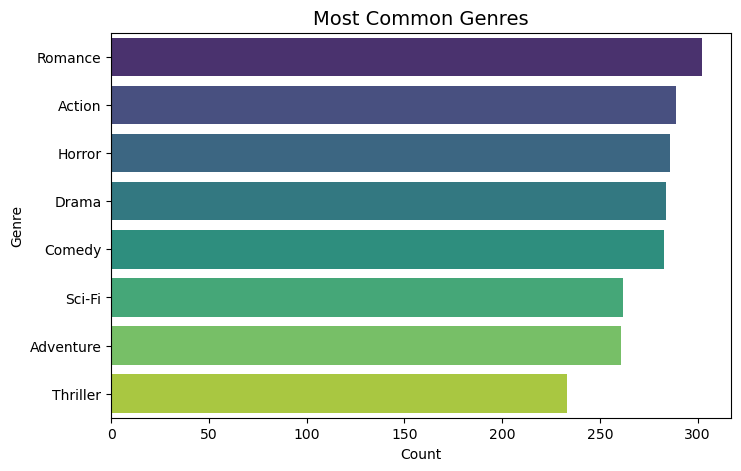

In [33]:
plt.figure(figsize=(8,5))
sns.countplot(y='Genre', data=df, order=df['Genre'].value_counts().index, palette='viridis')
plt.title('Most Common Genres', fontsize=14)
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()


### Observation:

 - Comedy and Action are the most frequent genres, suggesting that audiences favor light-hearted and high-energy content.

### Bivariate Analysis

### 4.Relationship Between Budget and Revenue

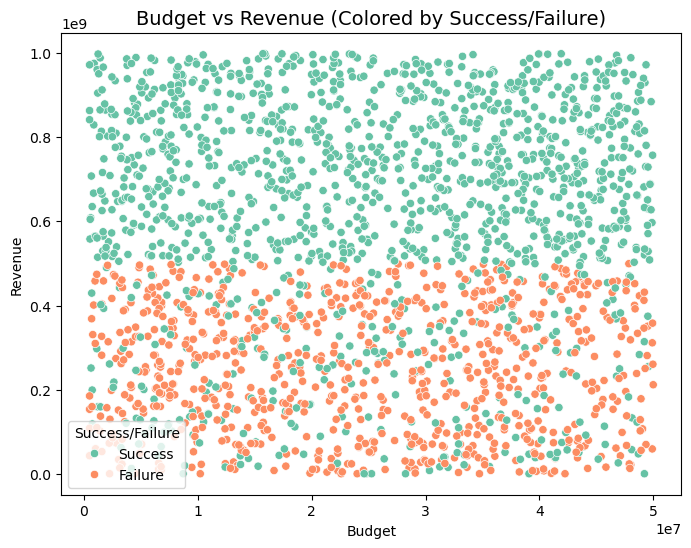

In [30]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Budget', y='Revenue', hue='Success/Failure', data=df, palette='Set2')
plt.title('Budget vs Revenue (Colored by Success/Failure)', fontsize=14)
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.show()


### Observation:
 - Successful shows generally have higher revenue for the same budget.
 - Failures cluster around low revenue despite moderate budgets.

### 5.Rating Comparison: Success vs Failure

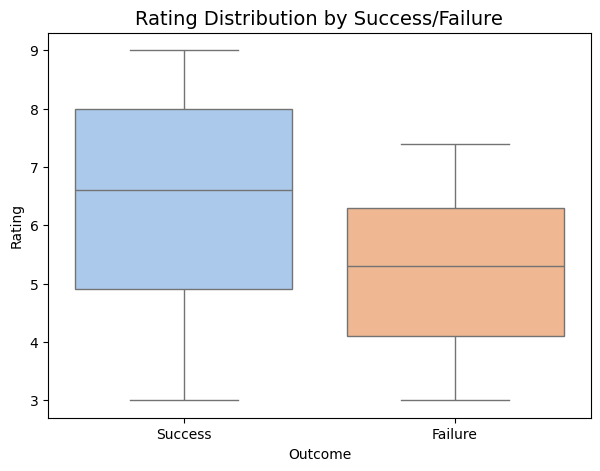

In [31]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Success/Failure', y='Rating', data=df, palette='pastel')
plt.title('Rating Distribution by Success/Failure', fontsize=14)
plt.xlabel('Outcome')
plt.ylabel('Rating')
plt.show()


### Observation:

 - Successful shows tend to have higher median ratings, suggesting that audience approval is a strong success factor.

### 6.Average Rating by Streaming Platform

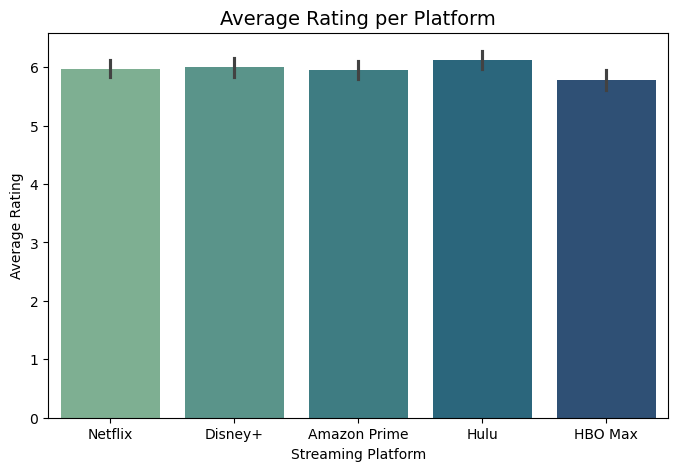

In [32]:
plt.figure(figsize=(8,5))
sns.barplot(x='StreamingPlatform', y='Rating', data=df, estimator='mean', palette='crest')
plt.title('Average Rating per Platform', fontsize=14)
plt.xlabel('Streaming Platform')
plt.ylabel('Average Rating')
plt.show()


### Observation:

 - Platforms like Amazon Prime and Netflix often have higher-rated shows, indicating better-quality or curated content.

### 7.Votes by Genre

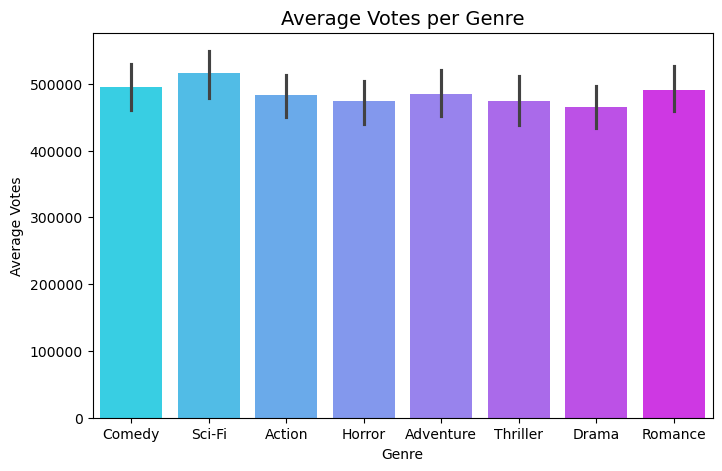

In [33]:
plt.figure(figsize=(8,5))
sns.barplot(x='Genre', y='Votes', data=df, estimator='mean', palette='cool')
plt.title('Average Votes per Genre', fontsize=14)
plt.xlabel('Genre')
plt.ylabel('Average Votes')
plt.show()


### Observation:

 - Action and Thriller genres receive more votes, reflecting higher audience engagement and popularity.

### Multivariate Analysis

### 8.Budget vs Revenue across Platforms and Success

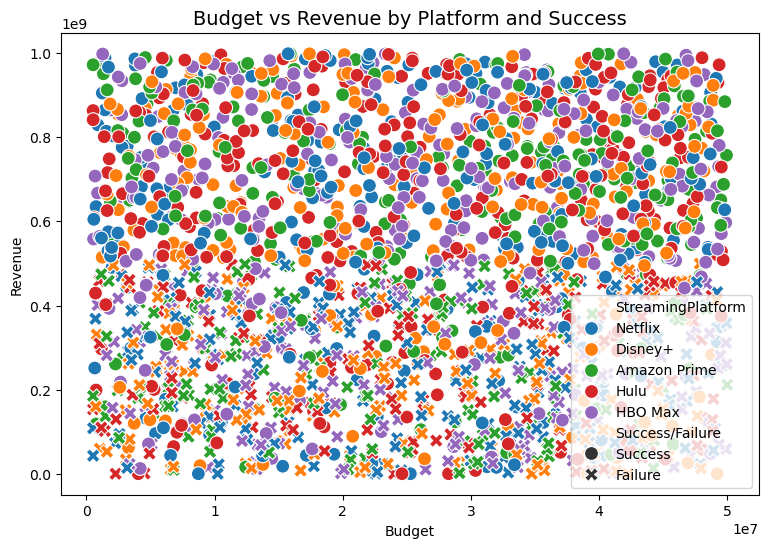

In [34]:
plt.figure(figsize=(9,6))
sns.scatterplot(x='Budget', y='Revenue', hue='StreamingPlatform', style='Success/Failure', data=df, s=100)
plt.title('Budget vs Revenue by Platform and Success', fontsize=14)
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.show()


### Observation:

 - Netflix and Disney+ shows dominate high-budget, high-revenue zones.
 - Failures mostly belong to smaller budgets and lesser-known platforms

### 9.Rating vs Revenue by Genre

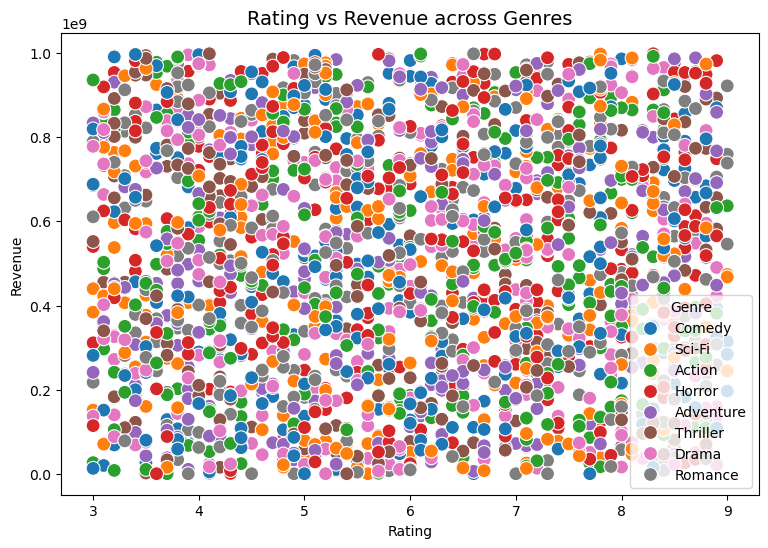

In [35]:
plt.figure(figsize=(9,6))
sns.scatterplot(x='Rating', y='Revenue', hue='Genre', data=df, palette='tab10', s=100)
plt.title('Rating vs Revenue across Genres', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Revenue')
plt.show()


### Observation:

 - Action and Sci-Fi genres show a strong positive correlation — higher ratings often translate to higher revenue.
 - Comedies have a weaker link between rating and revenue.

### 10. Votes vs Rating vs Success (with size as Revenue)

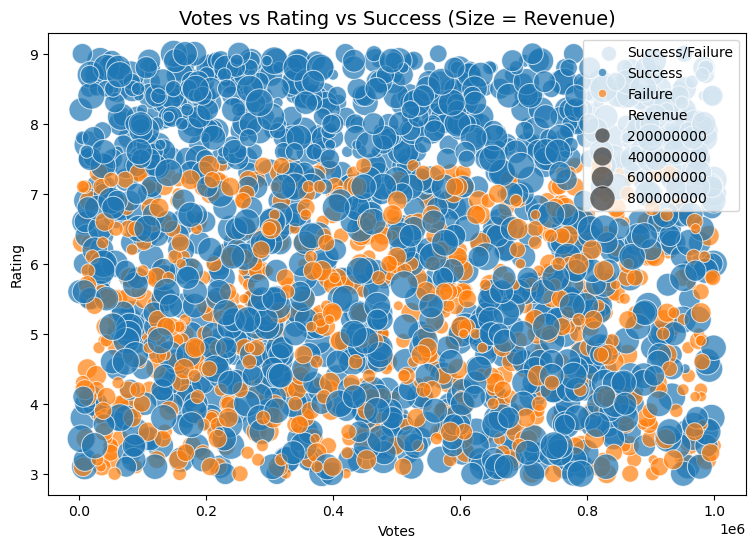

In [40]:
plt.figure(figsize=(9,6))
sns.scatterplot(x='Votes', y='Rating', hue='Success/Failure', size='Revenue', data=df, sizes=(50, 400), alpha=0.7)
plt.title('Votes vs Rating vs Success (Size = Revenue)', fontsize=14)
plt.xlabel('Votes')
plt.ylabel('Rating')
plt.show()


### Observation:

 - Successful shows often have high votes, high ratings, and large revenues — indicating strong audience traction and profitability.

### 11.Genre, Platform & Success Relationship

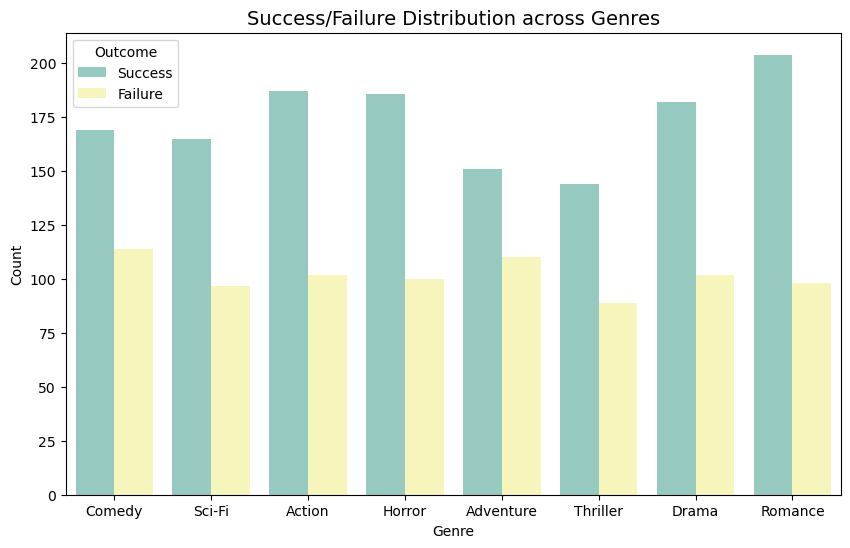

In [37]:
plt.figure(figsize=(10,6))
sns.countplot(x='Genre', hue='Success/Failure', data=df, palette='Set3')
plt.title('Success/Failure Distribution across Genres', fontsize=14)
plt.xlabel('Genre')
plt.ylabel('Count')
plt.legend(title='Outcome')
plt.show()


### Observation:

 - Some genres like Comedy and Adventure have higher success rates.
 - Horror and Sci-Fi show a relatively higher failure ratio.